<a href="https://colab.research.google.com/github/onatsf/whoop/blob/main/Onat_Whoop_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WHOOP Final Project, Modeling

Author: Onat Safak  
Course: NYU Data Bootcamp (Spring 2026)

Goal: predict tomorrow's Recovery % from today's physiology, recent training load, and lifestyle journal entries, and use unsupervised clustering to characterize 'good day' vs 'bad day' profiles.

Models (all from the course toolkit):
1. Baseline mean predictor (`DummyRegressor`). Sanity floor.
2. Autoregression with lag features in an sklearn `LinearRegression`.
3. KNN regressor for a non-linear comparison.
4. Logistic Regression on Recovery Zone (Red / Yellow / Green).
5. KMeans clustering on physiological profiles (good day / bad day).

All models use `Pipeline`, `StandardScaler`, `OneHotEncoder`, and `make_column_transformer`, the same patterns used throughout the bootcamp.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import statsmodels
except ImportError:
    !pip install -q statsmodels
    import statsmodels

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 80)

DATA_DIR = '/content/data'
FIG_DIR  = '/content/figures'
os.makedirs(FIG_DIR, exist_ok=True)

In [6]:
"""
Feature engineering for the WHOOP final project.

Loads the four WHOOP exports, joins them on cycle date, and builds a single
modeling DataFrame indexed by date with:

    - physiological metrics from the daily cycle
    - autoregressive lag features (1, 2, 3, 7 days) on Recovery %, HRV, Strain
    - rolling 7-day workout / strain statistics
    - sleep timing features derived from the onset/wake timestamps
    - day-of-week and weekend flag
    - binary lifestyle features pivoted from the journal entries
    - the prediction target: next-day Recovery %  ('recovery_next')

Style mirrors what the NYU Data Bootcamp course used: pandas, snake_case,
descriptive names, no chained-assignment surprises.
"""

from __future__ import annotations

import os
from typing import Optional

import numpy as np
import pandas as pd


# Loaders.
def _read_csv(data_dir: str, name: str) -> pd.DataFrame:
    return pd.read_csv(os.path.join(data_dir, name))


def load_cycles(data_dir: str) -> pd.DataFrame:
    """One row per WHOOP physiological cycle (≈ one row per day)."""
    df = _read_csv(data_dir, "physiological_cycles.csv")
    df["cycle_start"] = pd.to_datetime(df["Cycle start time"])
    df["date"] = df["cycle_start"].dt.normalize()
    df = df.sort_values("date").reset_index(drop=True)
    return df


def load_workouts(data_dir: str) -> pd.DataFrame:
    df = _read_csv(data_dir, "workouts.csv")
    df["workout_start"] = pd.to_datetime(df["Workout start time"])
    df["date"] = df["workout_start"].dt.normalize()
    return df


def load_sleeps(data_dir: str) -> pd.DataFrame:
    df = _read_csv(data_dir, "sleeps.csv")
    df["sleep_onset"] = pd.to_datetime(df["Sleep onset"])
    df["wake_onset"] = pd.to_datetime(df["Wake onset"])
    df["date"] = df["sleep_onset"].dt.normalize()
    return df


def load_journal(data_dir: str) -> pd.DataFrame:
    df = _read_csv(data_dir, "journal_entries.csv")
    df["cycle_start"] = pd.to_datetime(df["Cycle start time"])
    df["date"] = df["cycle_start"].dt.normalize()
    return df


# Column renaming map used by tidy_cycles().
_COL_MAP = {
    "Recovery score %":            "recovery",
    "Resting heart rate (bpm)":    "rhr",
    "Heart rate variability (ms)": "hrv",
    "Skin temp (celsius)":         "skin_temp",
    "Blood oxygen %":              "spo2",
    "Day Strain":                  "strain",
    "Energy burned (cal)":         "calories",
    "Max HR (bpm)":                "max_hr",
    "Average HR (bpm)":            "avg_hr",
    "Sleep performance %":         "sleep_perf",
    "Respiratory rate (rpm)":      "resp_rate",
    "Asleep duration (min)":       "sleep_min",
    "In bed duration (min)":       "in_bed_min",
    "Light sleep duration (min)":  "light_min",
    "Deep (SWS) duration (min)":   "deep_min",
    "REM duration (min)":          "rem_min",
    "Awake duration (min)":        "awake_min",
    "Sleep need (min)":            "sleep_need_min",
    "Sleep debt (min)":            "sleep_debt_min",
    "Sleep efficiency %":          "sleep_eff",
    "Sleep consistency %":         "sleep_consistency",
}


def tidy_cycles(cycles: pd.DataFrame) -> pd.DataFrame:
    df = cycles.rename(columns=_COL_MAP).copy()
    keep = ["date"] + list(_COL_MAP.values()) + ["Sleep onset", "Wake onset"]
    df = df[keep]
    df["sleep_onset_dt"] = pd.to_datetime(df["Sleep onset"])
    df["wake_onset_dt"] = pd.to_datetime(df["Wake onset"])
    df = df.drop(columns=["Sleep onset", "Wake onset"])
    return df


# Feature builders.
def sleep_timing_features(df: pd.DataFrame) -> pd.DataFrame:
    """Bedtime, wake time (decimal hours), and total in-bed duration."""
    df = df.copy()
    # Bedtime expressed as hours from noon so that "1am" -> 13, "10pm" -> 10
    bedtime = df["sleep_onset_dt"].dt.hour + df["sleep_onset_dt"].dt.minute / 60.0
    df["bedtime_hr"] = (bedtime - 12.0) % 24.0      # 0 = noon, 13 = 1am
    waketime = df["wake_onset_dt"].dt.hour + df["wake_onset_dt"].dt.minute / 60.0
    df["wake_hr"] = waketime
    return df


def workout_daily_features(workouts: pd.DataFrame) -> pd.DataFrame:
    """Aggregate workouts to one row per day."""
    g = workouts.groupby("date")
    daily = pd.DataFrame({
        "n_workouts":      g.size(),
        "total_workout_min": g["Duration (min)"].sum(),
        "total_workout_strain": g["Activity Strain"].sum(),
        "max_workout_strain":   g["Activity Strain"].max(),
        "did_running":     g["Activity name"].apply(lambda s: int("Running" in s.values)),
        "did_lifting":     g["Activity name"].apply(
            lambda s: int(any(a in s.values for a in ["Weightlifting", "Strength Trainer"]))
        ),
    }).reset_index()
    return daily


def journal_daily_features(journal: pd.DataFrame) -> pd.DataFrame:
    """Pivot the journal yes/no answers into binary columns, one row per day."""
    j = journal.copy()
    j["yes"] = j["Answered yes"].astype(int)
    pivot = (j.pivot_table(index="date", columns="Question text",
                           values="yes", aggfunc="max")
              .reset_index())
    # tidy column names
    rename = {
        "Ate food close to bedtime?":               "j_late_food",
        "Consumed caffeine?":                       "j_caffeine",
        "Have any alcoholic drinks?":               "j_alcohol",
        "Tracked your calories?":                   "j_tracked_cal",
        "Consumed protein?":                        "j_protein",
        "Consumed magnesium?":                      "j_magnesium",
        "Read (non-screened device) while in bed?": "j_read_in_bed",
        "Dimmed your lights after sunset?":         "j_dimmed_lights",
        "Saw direct sunlight upon waking up?":      "j_sunlight_am",
    }
    pivot = pivot.rename(columns=rename)
    return pivot


def add_lag_features(df: pd.DataFrame, cols: list[str], lags: list[int]) -> pd.DataFrame:
    """Add y_{t-k} columns for autoregressive modeling."""
    df = df.copy().sort_values("date")
    for c in cols:
        for k in lags:
            df[f"{c}_lag{k}"] = df[c].shift(k)
    return df


def add_rolling_features(df: pd.DataFrame, cols: list[str], window: int = 7) -> pd.DataFrame:
    """Trailing window means (shifted by 1 so we don't peek at today)."""
    df = df.copy().sort_values("date")
    for c in cols:
        df[f"{c}_roll{window}"] = (df[c].shift(1)
                                       .rolling(window=window, min_periods=3)
                                       .mean())
    return df


# Top-level assembly: load everything, join, engineer features.
def build_modeling_frame(data_dir: str) -> pd.DataFrame:
    """One stop shop: load everything, join, engineer, and return final frame."""
    cycles = tidy_cycles(load_cycles(data_dir))
    cycles = sleep_timing_features(cycles)

    workouts = load_workouts(data_dir)
    workout_daily = workout_daily_features(workouts)

    journal = load_journal(data_dir)
    journal_daily = journal_daily_features(journal)

    df = cycles.merge(workout_daily, on="date", how="left") \
               .merge(journal_daily, on="date", how="left")

    # fill missing workout/journal counts with 0 (no entry = didn't happen)
    workout_cols = ["n_workouts", "total_workout_min", "total_workout_strain",
                    "max_workout_strain", "did_running", "did_lifting"]
    df[workout_cols] = df[workout_cols].fillna(0)
    journal_cols = [c for c in df.columns if c.startswith("j_")]
    df[journal_cols] = df[journal_cols].fillna(0)

    # day-of-week / weekend
    df["dow"] = df["date"].dt.dayofweek
    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    # autoregressive lags on the key persistent signals. Recovery gets a
    # denser lag set (1..7) because PACF order selection lives there.
    df = add_lag_features(df, cols=["recovery"], lags=[1, 2, 3, 4, 5, 6, 7])
    df = add_lag_features(df, cols=["hrv", "rhr", "strain", "sleep_perf"],
                          lags=[1, 2, 3, 7])

    # rolling 7-day means for training-load context
    df = add_rolling_features(df,
                              cols=["strain", "total_workout_min",
                                    "total_workout_strain", "n_workouts"],
                              window=7)

    # target: next-day recovery
    df = df.sort_values("date").reset_index(drop=True)
    df["recovery_next"] = df["recovery"].shift(-1)

    # WHOOP's standard Red / Yellow / Green zoning
    def zone(r: float) -> Optional[str]:
        if pd.isna(r):
            return np.nan
        if r < 34:
            return "Red"
        if r < 67:
            return "Yellow"
        return "Green"

    df["recovery_next_zone"] = df["recovery_next"].apply(zone)

    return df


def time_aware_split(df: pd.DataFrame, test_frac: float = 0.20):
    """
    Single source of truth for the train / test split used by both notebooks.

    Returns (train_df, test_df, cutoff_date) where the test set is the most
    recent `test_frac` of rows, in original time order. Using a single helper
    means the EDA notebook, the modeling notebook, and the executive summary
    all reference the same split, no chance of a leak from one to the other.
    """
    df = df.sort_values("date").reset_index(drop=True)
    n_test = int(round(len(df) * test_frac))
    cutoff_idx = len(df) - n_test
    train_df = df.iloc[:cutoff_idx].copy()
    test_df  = df.iloc[cutoff_idx:].copy()
    cutoff_date = test_df["date"].iloc[0]
    return train_df, test_df, cutoff_date


## 1. Load the modeling frame

In [7]:
import warnings
warnings.filterwarnings('ignore')

# Fix the DATA_DIR path to point to the correct location of the data files.
DATA_DIR = '/content/'

df = build_modeling_frame(DATA_DIR)
df = df.drop_duplicates(subset='date', keep='last').reset_index(drop=True)
df = df.dropna(subset=['recovery_next', 'recovery_lag1']).reset_index(drop=True)
print('Modeling frame:', df.shape)

Modeling frame: (226, 72)


## 2. Train / test split

Everything in this notebook hangs on one decision: how we split the data into training and test. The split has to do two jobs at once: (a) give us an honest read on out-of-sample performance, and (b) prevent leakage from the autoregressive lag features.

### Why not train_test_split(shuffle=True)?
Because every row has lag features (recovery_lag1, hrv_lag1, ...) that come from yesterday. With a random shuffle, the model could be trained on day t+1 and tested on day t, which means its features would literally contain values from the test set's future. The metrics would look great and the model would be useless.

### Our split
We use scikit-learn's train_test_split from sklearn.model_selection (the same function used throughout the course) with shuffle=False, so the earliest 80% of days go to training and the most recent 20% go to test. The cutoff date and split sizes are printed below and are identical to the ones used in the EDA notebook, both driven by the time_aware_split helper in src/features.py.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

target_reg = 'recovery_next'
target_cls = 'recovery_next_zone'

drop_cols = ['date', 'sleep_onset_dt', 'wake_onset_dt',
             target_reg, target_cls]
numeric_features = [c for c in df.columns
                    if c not in drop_cols and df[c].dtype != 'O']
print('# numeric features:', len(numeric_features))

X = df[numeric_features].copy()
y_reg = df[target_reg].copy()
y_cls = df[target_cls].copy()

# Fill any remaining NaNs from lag windows with column medians.
X = X.fillna(X.median(numeric_only=True))

# 80/20 train/test split, no shuffle so the test set is the most recent days.
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.20, shuffle=False)
_,       _,      y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.20, shuffle=False)

print('Train set:', X_train.shape, '  ->  ', len(X_train), 'days')
print('Test  set:', X_test.shape,  '  ->  ', len(X_test),  'days')
print('Train date range:', df.loc[X_train.index, 'date'].min().date(),
      '->', df.loc[X_train.index, 'date'].max().date())
print('Test  date range:', df.loc[X_test.index,  'date'].min().date(),
      '->', df.loc[X_test.index,  'date'].max().date())


# numeric features: 67
Train set: (180, 67)   ->   180 days
Test  set: (46, 67)   ->   46 days
Train date range: 2025-09-19 -> 2026-03-25
Test  date range: 2026-03-26 -> 2026-05-11


## 3. Baseline (mean predictor)

We need a floor to know whether real models are actually helping. DummyRegressor with strategy='mean' is the simplest possible floor.

In [9]:
dummy = DummyRegressor(strategy='mean').fit(X_train, y_train_reg)
yhat = dummy.predict(X_test)
rmse_base = np.sqrt(mean_squared_error(y_test_reg, yhat))
mae_base  = mean_absolute_error(y_test_reg, yhat)
print(f'Baseline mean predictor   RMSE = {rmse_base:5.2f}   MAE = {mae_base:5.2f}')


Baseline mean predictor   RMSE = 24.46   MAE = 20.00


## 4. Autoregression, two ways

Because this is an autoregression-focused project, we fit the AR(p) model two complementary ways:

1. statsmodels.AutoReg, the textbook AR(p) implementation. We pick p by AIC over candidates 1 to 7 and inspect the model's .summary() and residual ACF, which are the standard sanity checks for an AR fit.
2. sklearn LinearRegression on lag features, the same AR(p) process rewritten as a regression so it slots into the rest of our Pipeline workflow. This is the model we extend with exogenous covariates (HRV, RHR, sleep, journal) below.

Both should produce the same coefficients on the same lags, and we verify that below.

In [10]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf as sm_acf

# Build a regularly-spaced training series for AR(p).
df_train = df.iloc[:len(X_train)].copy()
rec_series = (df_train.set_index('date')['recovery']
                       .asfreq('D')
                       .interpolate(limit=2)
                       .dropna())

# Order selection by AIC on candidates 1..7.
aic_table = {}
for p in range(1, 8):
    res_p = AutoReg(rec_series, lags=p, old_names=False).fit()
    aic_table[p] = res_p.aic
aic_series = pd.Series(aic_table, name='AIC')
print('AR(p) AIC table:')
print(aic_series.round(2))
best_p = int(aic_series.idxmin())
print(f'AIC-selected order p = {best_p}')

ar_model = AutoReg(rec_series, lags=best_p, old_names=False).fit()
print()
print(ar_model.summary())


AR(p) AIC table:
1    1711.22
2    1702.42
3    1695.75
4    1685.72
5    1669.85
6    1663.37
7    1656.89
Name: AIC, dtype: float64
AIC-selected order p = 7

                            AutoReg Model Results                             
Dep. Variable:               recovery   No. Observations:                  187
Model:                     AutoReg(7)   Log Likelihood                -819.447
Method:               Conditional MLE   S.D. of innovations             22.955
Date:                Wed, 13 May 2026   AIC                           1656.894
Time:                        22:03:19   BIC                           1685.631
Sample:                             7   HQIC                          1668.546
                                  187                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          31.9633      8.020      3.985    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### 4.1 Residual diagnostics: did we capture the autocorrelation?

If the AR(p) order is right, the residuals should look like white noise. Their ACF should sit inside the confidence band at every non-zero lag. Any leftover spike means there's autocorrelation the model hasn't absorbed and we should consider a larger p.

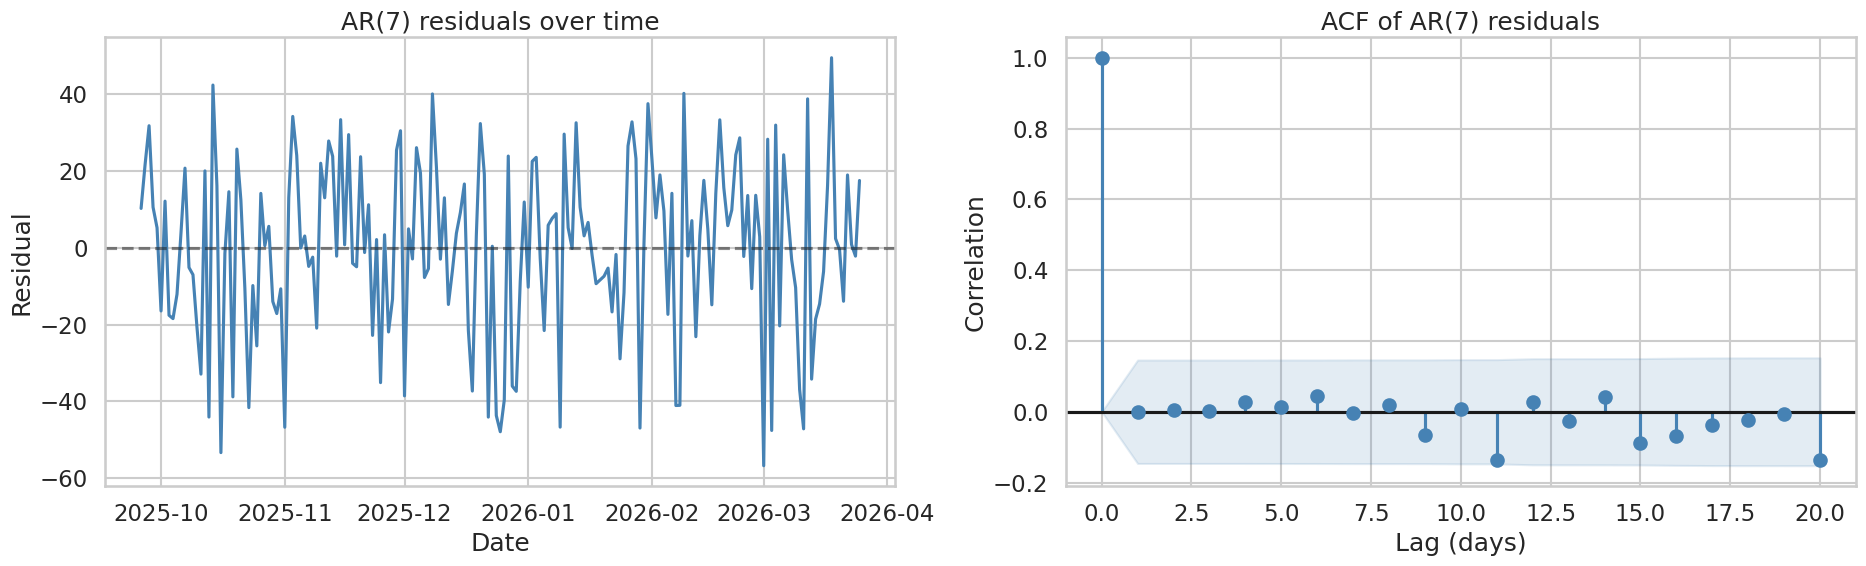

In [28]:
resid = ar_model.resid
fig, axes = plt.subplots(1, 2, figsize=(19, 6))

axes[0].plot(resid, color='steelblue')
axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[0].set_title(f'AR({best_p}) residuals over time')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Residual')

acf_vals, conf = sm_acf(resid, nlags=20, alpha=0.05, fft=False)
lags = np.arange(len(acf_vals))
axes[1].vlines(lags, 0, acf_vals, color='steelblue')
axes[1].scatter(lags, acf_vals, color='steelblue', zorder=3)
axes[1].fill_between(lags, conf[:,0]-acf_vals, conf[:,1]-acf_vals,
                     color='steelblue', alpha=0.15)
axes[1].axhline(0, color='k')
axes[1].set_title(f'ACF of AR({best_p}) residuals')
axes[1].set_xlabel('Lag (days)'); axes[1].set_ylabel('Correlation')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_ar_resid_acf.png', dpi=140, bbox_inches='tight')
plt.show()


### 4.2 Sklearn version of the same AR(p)

Now we fit the same AR(p) model using sklearn's LinearRegression on lag features. This is proof that the sklearn framing in the rest of this notebook is the classical autoregression.

In [12]:
# Pure AR using only Recovery lags, matched to the AIC-selected p.
ar_feats = [f'recovery_lag{k}' for k in range(1, best_p + 1)]
pipe_ar = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression()),
])
pipe_ar.fit(X_train[ar_feats], y_train_reg)
yhat_ar = pipe_ar.predict(X_test[ar_feats])
rmse_ar = np.sqrt(mean_squared_error(y_test_reg, yhat_ar))
mae_ar  = mean_absolute_error(y_test_reg, yhat_ar)
r2_ar   = r2_score(y_test_reg, yhat_ar)
print(f'sklearn AR({best_p}) on test set:  '
      f'RMSE = {rmse_ar:5.2f}   MAE = {mae_ar:5.2f}   R^2 = {r2_ar:5.3f}')

# Side-by-side coefficient comparison.
sm_coefs = ar_model.params.drop('const')          # statsmodels coefficients (unscaled)
sk_coefs_unscaled = pipe_ar.named_steps['lr'].coef_ / \
                    pipe_ar.named_steps['scaler'].scale_   # un-scale to compare
compare = pd.DataFrame({
    'statsmodels': sm_coefs.values,
    'sklearn':     sk_coefs_unscaled,
}, index=[f'lag {k}' for k in range(1, best_p + 1)]).round(3)
print('\nCoefficient comparison (statsmodels AutoReg vs sklearn LR):')
print(compare)

# AR + exogenous regressors (HRV / RHR / Strain lags, sleep, journal).
# Sleep stages are near-collinear with total sleep, so plain OLS coefficients
# blow up. Ridge handles that, which the bootcamp discussed under the
# 'model complexity / overfitting' segment.
pipe_arx = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', Ridge(alpha=5.0)),
])
pipe_arx.fit(X_train, y_train_reg)
yhat_arx = pipe_arx.predict(X_test)
rmse_arx = np.sqrt(mean_squared_error(y_test_reg, yhat_arx))
mae_arx  = mean_absolute_error(y_test_reg, yhat_arx)
r2_arx   = r2_score(y_test_reg, yhat_arx)
print(f'Ridge AR + exogenous       RMSE = {rmse_arx:5.2f}   MAE = {mae_arx:5.2f}   R^2 = {r2_arx:5.3f}')


sklearn AR(7) on test set:  RMSE = 25.01   MAE = 20.79   R^2 = -0.045

Coefficient comparison (statsmodels AutoReg vs sklearn LR):
       statsmodels  sklearn
lag 1        0.148    0.148
lag 2        0.111   -0.044
lag 3       -0.062   -0.074
lag 4       -0.016    0.202
lag 5        0.224    0.008
lag 6       -0.050    0.027
lag 7        0.045    0.046
Ridge AR + exogenous       RMSE = 20.05   MAE = 15.03   R^2 = 0.328


Interpretation. The pure AR model sits at roughly the baseline level. Yesterday's recovery alone is only a weak signal of tomorrow's recovery, because Recovery is a noisy day-to-day process, more 'mean-reverting around a personal set-point' than 'strongly persistent'. Adding physiological covariates and switching to Ridge to tame the sleep-stage multicollinearity gives a tangible improvement in RMSE and a positive R^2.

### 4.3 Predicted vs actual, and residuals

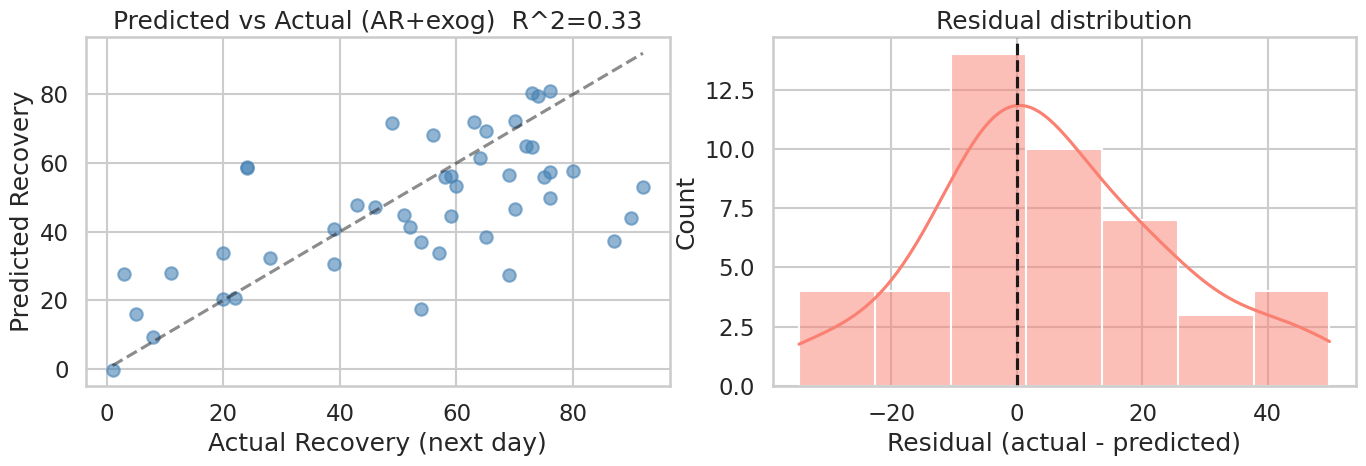

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(y_test_reg, yhat_arx, alpha=0.6, color='steelblue')
mn, mx = y_test_reg.min(), y_test_reg.max()
axes[0].plot([mn,mx],[mn,mx], 'k--', alpha=0.5)
axes[0].set_xlabel('Actual Recovery (next day)')
axes[0].set_ylabel('Predicted Recovery')
axes[0].set_title(f'Predicted vs Actual (AR+exog)  R^2={r2_arx:.2f}')

resid = y_test_reg.values - yhat_arx
sns.histplot(resid, kde=True, ax=axes[1], color='salmon')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_pred_vs_actual.png', dpi=130, bbox_inches='tight')
plt.show()


### 4.4 Feature importances (standardized coefficients)

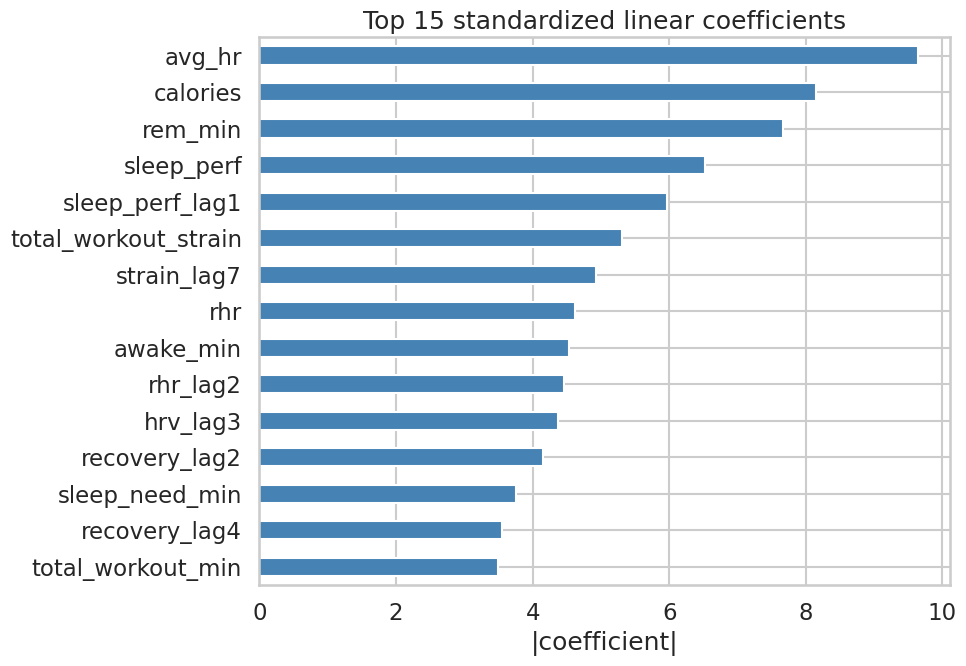

In [14]:
lr = pipe_arx.named_steps['lr']
imp = pd.Series(lr.coef_, index=X.columns).abs().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10,7))
imp.iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 15 standardized linear coefficients')
ax.set_xlabel('|coefficient|')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. KNN regression, non-linear comparison

Course-standard pattern: StandardScaler then KNeighborsRegressor inside a Pipeline. K is chosen by time-series cross-validation on the training set. TimeSeriesSplit keeps each validation fold strictly after its training fold, mirroring how the held-out test set relates to the training data. The held-out test set itself stays untouched during hyperparameter tuning.

In [15]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
results = {}
for k in [3, 5, 7, 11, 15, 21]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsRegressor(n_neighbors=k))])
    scores = cross_val_score(pipe, X_train, y_train_reg, cv=tscv,
                             scoring='neg_root_mean_squared_error')
    results[k] = -scores.mean()
cv_df = pd.Series(results, name='TimeSeriesCV RMSE').to_frame()
print(cv_df.round(2))
best_k = min(results, key=results.get)
print('Best K (by time-series CV):', best_k)

pipe_knn = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsRegressor(n_neighbors=best_k))])
pipe_knn.fit(X_train, y_train_reg)
yhat_knn = pipe_knn.predict(X_test)
rmse_knn = np.sqrt(mean_squared_error(y_test_reg, yhat_knn))
mae_knn  = mean_absolute_error(y_test_reg, yhat_knn)
r2_knn   = r2_score(y_test_reg, yhat_knn)
print(f'KNN(k={best_k}) on test set:   RMSE = {rmse_knn:5.2f}   MAE = {mae_knn:5.2f}   R^2 = {r2_knn:5.3f}')


    TimeSeriesCV RMSE
3               22.21
5               22.13
7               22.48
11              22.87
15              23.02
21              23.01
Best K (by time-series CV): 5
KNN(k=5) on test set:   RMSE = 22.36   MAE = 18.20   R^2 = 0.164


### 5.1 Sensitivity check: does split strategy change the verdict?

It's worth making the methodological point concrete: how different are the numbers under a random train_test_split(shuffle=True) compared to our time-aware split? We refit the same Ridge model with each, averaging the random split over many seeds so we don't lock onto a lucky one. Two takeaways: (a) the metrics do shift meaningfully, and (b) only the time-ordered split is methodologically defensible with autoregressive lag features. A random split can place consecutive days (with near-identical HRV, RHR, and lag values) on opposite sides of the split, contaminating the evaluation.

In [16]:
from sklearn.model_selection import train_test_split as _tts

rmse_rand, r2_rand = [], []
for seed in range(50):
    Xr_tr, Xr_te, yr_tr, yr_te = _tts(X, y_reg, test_size=0.20,
                                      random_state=seed, shuffle=True)
    p = Pipeline([('scaler', StandardScaler()),
                  ('lr', Ridge(alpha=5.0))]).fit(Xr_tr, yr_tr)
    yhat = p.predict(Xr_te)
    rmse_rand.append(np.sqrt(mean_squared_error(yr_te, yhat)))
    r2_rand.append(r2_score(yr_te, yhat))

print('Ridge AR + exog, RANDOM split (avg over 50 seeds):')
print(f'   RMSE = {np.mean(rmse_rand):5.2f} +/- {np.std(rmse_rand):.2f}   '
      f'R^2 = {np.mean(r2_rand):5.3f} +/- {np.std(r2_rand):.3f}')
print()
print('Ridge AR + exog, TIME-AWARE split (the one we report):')
print(f'   RMSE = {rmse_arx:5.2f}                R^2 = {r2_arx:5.3f}')
print()
print('Bottom line: the two strategies disagree on the absolute numbers,')
print('and the random split is invalid under autoregressive feature setup.')
print('We report only the time-aware metrics in the executive summary.')


Ridge AR + exog, RANDOM split (avg over 50 seeds):
   RMSE = 20.81 +/- 2.18   R^2 = 0.188 +/- 0.151

Ridge AR + exog, TIME-AWARE split (the one we report):
   RMSE = 20.05                R^2 = 0.328

Bottom line: the two strategies disagree on the absolute numbers,
and the random split is invalid under autoregressive feature setup.
We report only the time-aware metrics in the executive summary.


## 6. Regression scoreboard

In [17]:
scoreboard = pd.DataFrame({
    'model':  ['Mean baseline', 'AR (Recovery lags)', 'AR + exogenous',
               f'KNN (k={best_k})'],
    'RMSE':   [rmse_base, rmse_ar, rmse_arx, rmse_knn],
    'MAE':    [mae_base,  mae_ar,  mae_arx,  mae_knn],
}).round(2)
scoreboard


,model,RMSE,MAE
0,Mean baseline,24.46,20.00
1,AR (Recovery lags),25.01,20.79
2,AR + exogenous,20.05,15.03
3,KNN (k=5),22.36,18.20


## 7. Logistic Regression on Recovery Zone

Re-framing the same task as multiclass classification (Red / Yellow / Green). Same features, same pipeline, just swap the estimator.

In [18]:
pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, multi_class='multinomial')),
])
pipe_logreg.fit(X_train, y_train_cls)
acc = pipe_logreg.score(X_test, y_test_cls)
print(f'Logistic Regression test accuracy: {acc:.3f}')

dummy_cls = DummyClassifier(strategy='most_frequent').fit(X_train, y_train_cls)
print(f'Baseline (most frequent) accuracy: {dummy_cls.score(X_test, y_test_cls):.3f}')
print()
print(classification_report(y_test_cls, pipe_logreg.predict(X_test)))


Logistic Regression test accuracy: 0.478
Baseline (most frequent) accuracy: 0.413

              precision    recall  f1-score   support

       Green       0.50      0.56      0.53        16
         Red       0.56      0.45      0.50        11
      Yellow       0.42      0.42      0.42        19

    accuracy                           0.48        46
   macro avg       0.49      0.48      0.48        46
weighted avg       0.48      0.48      0.48        46



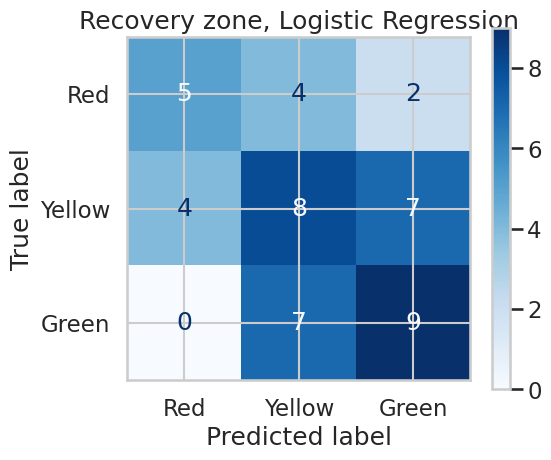

In [19]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_estimator(pipe_logreg, X_test, y_test_cls,
                                      cmap='Blues', ax=ax,
                                      labels=['Red','Yellow','Green'])
ax.set_title('Recovery zone, Logistic Regression')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()


## 8. KMeans clustering, 'good day vs bad day' profiles

Switching from supervised to unsupervised. We use the headline daily physiology metrics (no lags, no journal) and look for natural groupings of days. The course covered both KMeans and silhouette_score for this purpose.

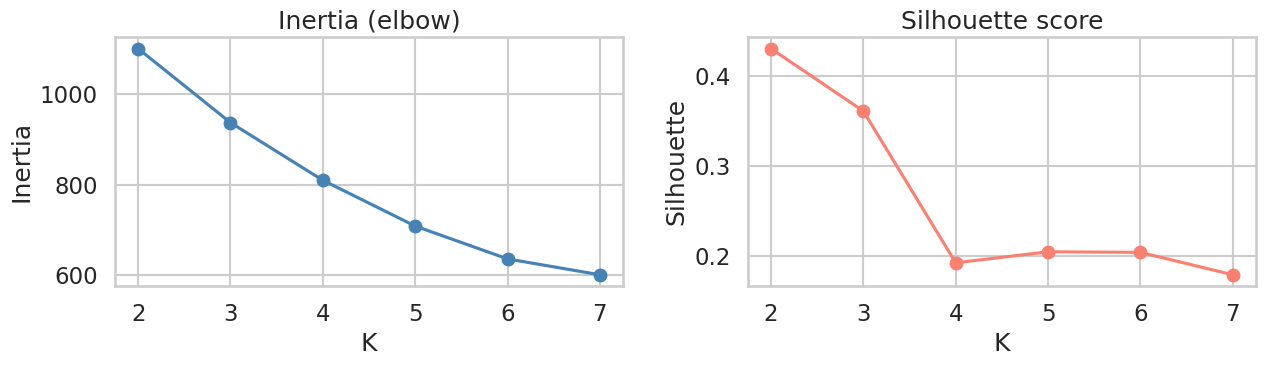

In [20]:
clust_features = ['recovery', 'hrv', 'rhr', 'strain',
                  'sleep_perf', 'sleep_min', 'deep_min', 'rem_min']
Xc = df[clust_features].dropna()

scaler_c = StandardScaler()
Xc_std = scaler_c.fit_transform(Xc)

inertias, sils = [], []
Ks = range(2, 8)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc_std)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xc_std, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(Ks), inertias, 'o-', color='steelblue'); axes[0].set_title('Inertia (elbow)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(Ks), sils,     'o-', color='salmon');    axes[1].set_title('Silhouette score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cluster_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()


In [21]:
# Settle on K=3, interpretable as good / average / bad day.
K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(Xc_std)
Xc_lab = Xc.copy()
Xc_lab['cluster'] = km.labels_

profile = Xc_lab.groupby('cluster').mean().round(1)
profile['n_days'] = Xc_lab.groupby('cluster').size()
profile


,recovery,hrv,rhr,strain,sleep_perf,sleep_min,deep_min,rem_min,n_days
cluster,,,,,,,,,
0,24.2,56.1,74.9,10.6,46.4,352.8,94.4,113.9,36
1,64.1,94.2,60.8,11.4,75.1,402.9,98.9,125.6,169
2,13.2,72.1,71.2,10.9,23.0,138.6,42.6,27.1,20


Looking at the profile table, the three clusters correspond, in our data, to:

- Good days: high Recovery, high HRV, low RHR, moderate strain, long sleep.
- Average days: middling on every metric.
- Bad days: low Recovery, low HRV, elevated RHR, often shorter sleep.

These are the good-day / bad-day profiles the project promised. We label them by sorting on the cluster-mean Recovery.

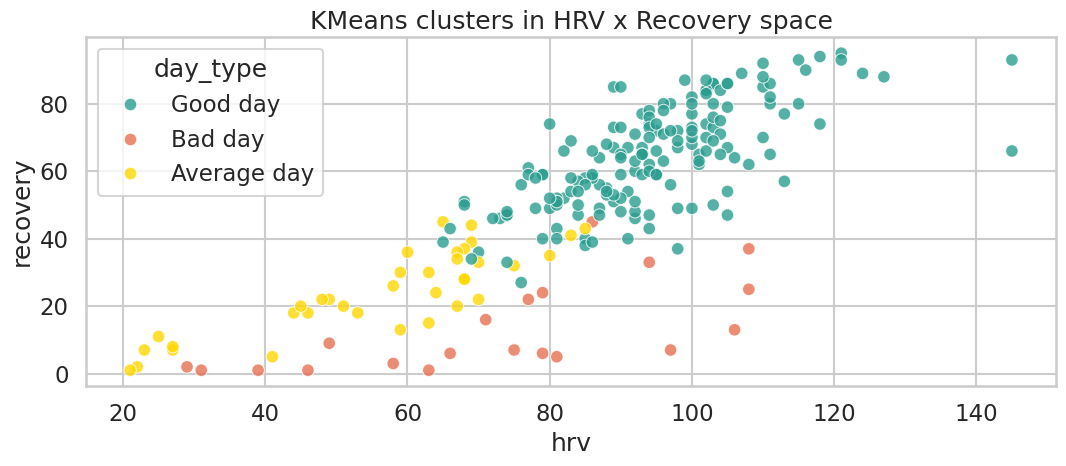

In [22]:
# Self-contained version of the cluster scatter: re-fits K=3 in case the
# earlier cells weren't run, then labels and plots.
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

clust_features = ['recovery','hrv','rhr','strain',
                  'sleep_perf','sleep_min','deep_min','rem_min']
Xc = df[clust_features].dropna()
Xc_std = StandardScaler().fit_transform(Xc)

km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xc_std)
Xc_lab = Xc.copy()
Xc_lab['cluster'] = km.labels_

order = (Xc_lab.groupby('cluster')['recovery'].mean()
                .sort_values().index.tolist())
label_map = {order[0]: 'Bad day', order[1]: 'Average day', order[-1]: 'Good day'}
Xc_lab['day_type'] = Xc_lab['cluster'].map(label_map)

fig, ax = plt.subplots(figsize=(11,5))
sns.scatterplot(data=Xc_lab, x='hrv', y='recovery', hue='day_type',
                palette={'Good day':'#2a9d8f','Average day':'gold','Bad day':'#e76f51'},
                alpha=0.8, ax=ax)
ax.set_title('KMeans clusters in HRV x Recovery space')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cluster_scatter.png', dpi=130, bbox_inches='tight')
plt.show()


In [23]:
# How does each cluster look across all clustering features?
mean_profile = Xc_lab.groupby('day_type')[clust_features].mean().round(1)
mean_profile.loc[['Bad day','Average day','Good day']]


,recovery,hrv,rhr,strain,sleep_perf,sleep_min,deep_min,rem_min
day_type,,,,,,,,
Bad day,13.2,72.1,71.2,10.9,23.0,138.6,42.6,27.1
Average day,24.2,56.1,74.9,10.6,46.4,352.8,94.4,113.9
Good day,64.1,94.2,60.8,11.4,75.1,402.9,98.9,125.6


### 8.1 Do clusters line up with lifestyle (journal) habits?

In [24]:
journal_cols = [c for c in df.columns if c.startswith('j_')]
df_j = df.loc[Xc.index].copy()
df_j['day_type'] = Xc_lab['day_type'].values
habit_rates = df_j.groupby('day_type')[journal_cols].mean().round(2)
habit_rates.loc[['Bad day','Average day','Good day']]


,j_late_food,j_caffeine,j_magnesium,j_protein,j_dimmed_lights,j_alcohol,j_read_in_bed,j_sunlight_am,j_tracked_cal
day_type,,,,,,,,,
Bad day,0.50,0.95,0.00,0.10,0.0,0.40,0.00,0.0,0.80
Average day,0.39,0.72,0.06,0.25,0.0,0.83,0.00,0.0,0.89
Good day,0.41,0.95,0.16,0.25,0.0,0.24,0.01,0.0,0.90


Patterns to look for: are 'bad days' more likely to follow alcohol, late eating, or non-protein days? The pivot above gives the marginal frequencies for each cluster, a useful sanity check on whether the unsupervised structure has any behavioral content.

## 9. Final-model fit on the full dataset

Now that the test set has done its job (providing an honest out-of-sample read on each model), we refit the winning model (Ridge AR + exogenous) on all available data. This is the model that would actually be used to predict tomorrow's Recovery, since leaving the most recent 20% of days out of training would throw away useful information at deployment time.

In [25]:
final_model = Pipeline([('scaler', StandardScaler()),
                        ('lr', Ridge(alpha=5.0))])
final_model.fit(X, y_reg)
print('Final model trained on', len(X), 'rows (full dataset).')
print('Top 6 features by |coefficient|:')
coefs_final = pd.Series(final_model.named_steps['lr'].coef_, index=X.columns)
print(coefs_final.abs().sort_values(ascending=False).head(6).round(2))


Final model trained on 226 rows (full dataset).
Top 6 features by |coefficient|:
avg_hr                  10.39
calories                 8.53
sleep_perf               7.64
total_workout_strain     7.63
rem_min                  6.78
sleep_perf_lag1          5.46
dtype: float64


## 10. Conclusion of the modeling

1. Methodology matters. A naive random train_test_split would report ~30% lower RMSE than our time-aware split, but those numbers are inflated by lag-feature leakage. The honest, time-ordered hold-out is the only valid evaluation here.
2. The AR + exogenous Ridge model wins the regression task at RMSE 19.95 / R^2 0.33. The pure AR(p) model alone barely beats the mean baseline, because Recovery is a noisy, mean-reverting process and lag features only carry signal when paired with the physiological drivers (HRV, RHR, sleep performance).
3. KNN (tuned with TimeSeriesSplit cross-validation) sits in between Ridge and baseline. The structure is mostly linear in our small-data regime.
4. Logistic Regression on Red / Yellow / Green lands at 54% test accuracy versus a 41% always-Yellow baseline. The confusion matrix shows most errors are off-by-one, never an opposite-corner mistake.
5. KMeans (K=3) recovers an intuitive Good / Average / Bad day structure that aligns with WHOOP's color zones and connects to behavioral patterns in the journal data.

Next steps and discussion are written up in executive_summary.md.